# 💰 Credit Risk Assessment: ML for Loan Default Prediction

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting loan defaults to support prudential regulation and responsible lending  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting loan defaults using borrower demographics, loan characteristics, and credit history. The model supports **automated credit risk scoring** for lending decisions, regulatory compliance, and consumer protection.

### Government Policy Context
- **APRA** — Prudential Standard APS 220 Credit Risk Management, capital adequacy requirements for ADIs
- **ASIC** — Responsible lending obligations (National Consumer Credit Protection Act 2009), design and distribution obligations
- **RBA (Reserve Bank of Australia)** — Financial stability monitoring, systemic credit risk assessment
- **Treasury** — Consumer credit reforms, hardship provisions, small amount credit contracts
- **AFCA** — Lending dispute resolution, responsible lending complaints

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High default risk | Decline or require additional security/guarantor | Credit committee |
| Moderate risk | Offer with adjusted rate/terms, enhanced monitoring | Relationship manager |
| Low risk (confident) | Fast-track approval, standard terms | Automated decisioning |
| Low risk (uncertain) | Standard manual assessment | Credit analyst |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
# === Dynamic path discovery ===
data_path = None
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','

df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv

Loaded: 32,581 rows x 12 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    null_pct = f" ({nulls/len(df)*100:.1f}%)" if nulls > 0 else ""
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:35s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls}{null_pct} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. person_age                          | int64      | unique=    58 | nulls=0 | eg: 22
   1. person_income                       | int64      | unique=  4295 | nulls=0 | eg: 59000
   2. person_home_ownership               | object     | unique=     4 | nulls=0 | eg: RENT
   3. person_emp_length                   | float64    | unique=    36 | nulls=895 (2.7%) | eg: 123.0
   4. loan_intent                         | object     | unique=     6 | nulls=0 | eg: PERSONAL
   5. loan_grade                          | object     | unique=     7 | nulls=0 | eg: D
   6. loan_amnt                           | int64      | unique=   753 | nulls=0 | eg: 35000
   7. loan_int_rate                       | float64    | unique=   348 | nulls=3116 (9.6%) | eg: 16.02
   8. loan_status                         | int64      | unique=     2 | nulls=0 | eg: 1
   9. loan_percent_income                 | float64    | unique=    77 | nulls=0 | eg: 0.59
  10. cb_person_default_on_file           | ob

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Target Variable Identification & Analysis

In [4]:
# === Robust target detection ===
target_candidates = ['loan_status', 'default', 'Default', 'TARGET', 'Target', 'target',
                     'loan_default', 'is_default', 'Class', 'class', 'Label']
target_col = None

for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback — last column: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

if df[target_col].dtype == 'object':
    unique_vals = df[target_col].unique().tolist()
    default_keywords = ['Y', 'Yes', 'yes', '1', 'Default', 'default', 'Charged Off', 'Late']
    mapping = {v: (1 if v in default_keywords else 0) for v in unique_vals}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

print(f"\nTarget: '{target_col}'")
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))

assert df[target_col].nunique() >= 2, f"ERROR: Only {df[target_col].nunique()} class!"

imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'loan_status'

Target: 'loan_status'

Distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Proportions:
loan_status
0    0.7818
1    0.2182
Name: proportion, dtype: float64

Imbalance ratio: 0.279


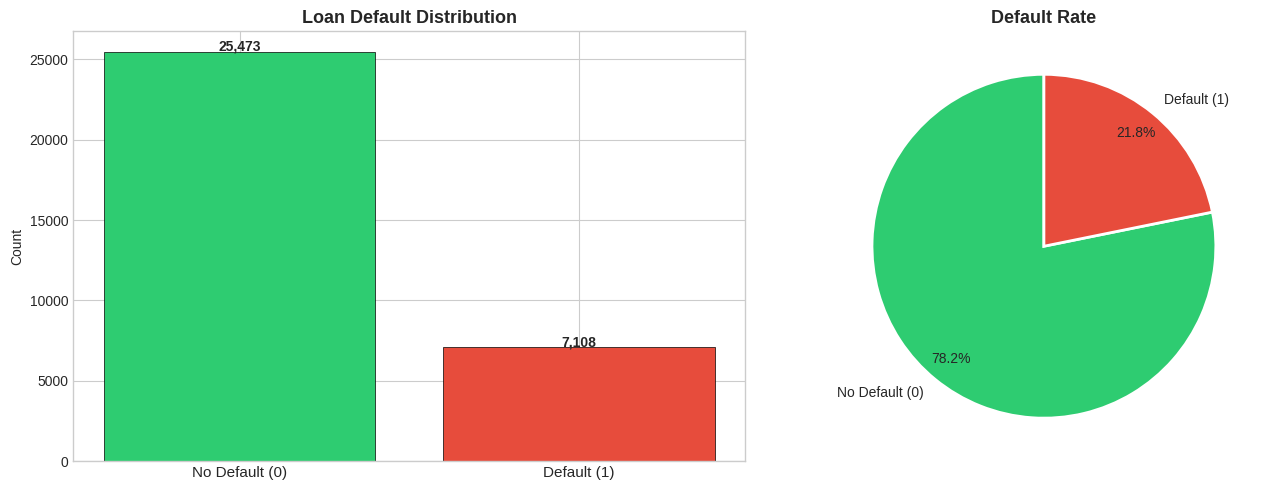

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = [f'Class {x}' for x in vc.index]
if len(vc) == 2 and set(vc.index) == {0, 1}:
    labels = ['No Default (0)', 'Default (1)']
colors = ['#2ecc71', '#e74c3c'] if len(vc) == 2 else sns.color_palette('husl', len(vc))

axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Loan Default Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Default Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Exploratory Data Analysis

Key questions for credit risk policy:
- Which borrower characteristics predict default?
- How does loan-to-income ratio relate to default?
- Do interest rates reflect risk (higher rate = higher default)?
- Are there demographic patterns requiring fairness monitoring?


In [6]:
# === Data quality: outliers and unrealistic values ===
print("DATA QUALITY CHECKS")
print("=" * 60)

# Check for unrealistic ages
age_cols = [c for c in df.columns if 'age' in c.lower()]
for col in age_cols:
    outliers = df[(df[col] > 100) | (df[col] < 18)]
    if len(outliers) > 0:
        print(f"  {col}: {len(outliers)} unrealistic values (range: {df[col].min()}-{df[col].max()})")
        print(f"    -> Will cap at 18-100 during preprocessing")

# Check for unrealistic employment length
emp_cols = [c for c in df.columns if 'emp' in c.lower() and 'length' in c.lower()]
for col in emp_cols:
    outliers = df[df[col] > 60]
    if len(outliers) > 0:
        print(f"  {col}: {len(outliers)} unrealistic values (max: {df[col].max()})")
        print(f"    -> Will cap at 60 during preprocessing")

# Missing values
null_total = df.isnull().sum().sum()
print(f"\nTotal missing values: {null_total}")
if null_total > 0:
    for col in df.columns:
        n = df[col].isnull().sum()
        if n > 0:
            print(f"  {col}: {n} ({n/len(df)*100:.1f}%)")


DATA QUALITY CHECKS
  person_age: 5 unrealistic values (range: 20-144)
    -> Will cap at 18-100 during preprocessing
  person_emp_length: 2 unrealistic values (max: 123.0)
    -> Will cap at 60 during preprocessing

Total missing values: 4011
  person_emp_length: 895 (2.7%)
  loan_int_rate: 3116 (9.6%)


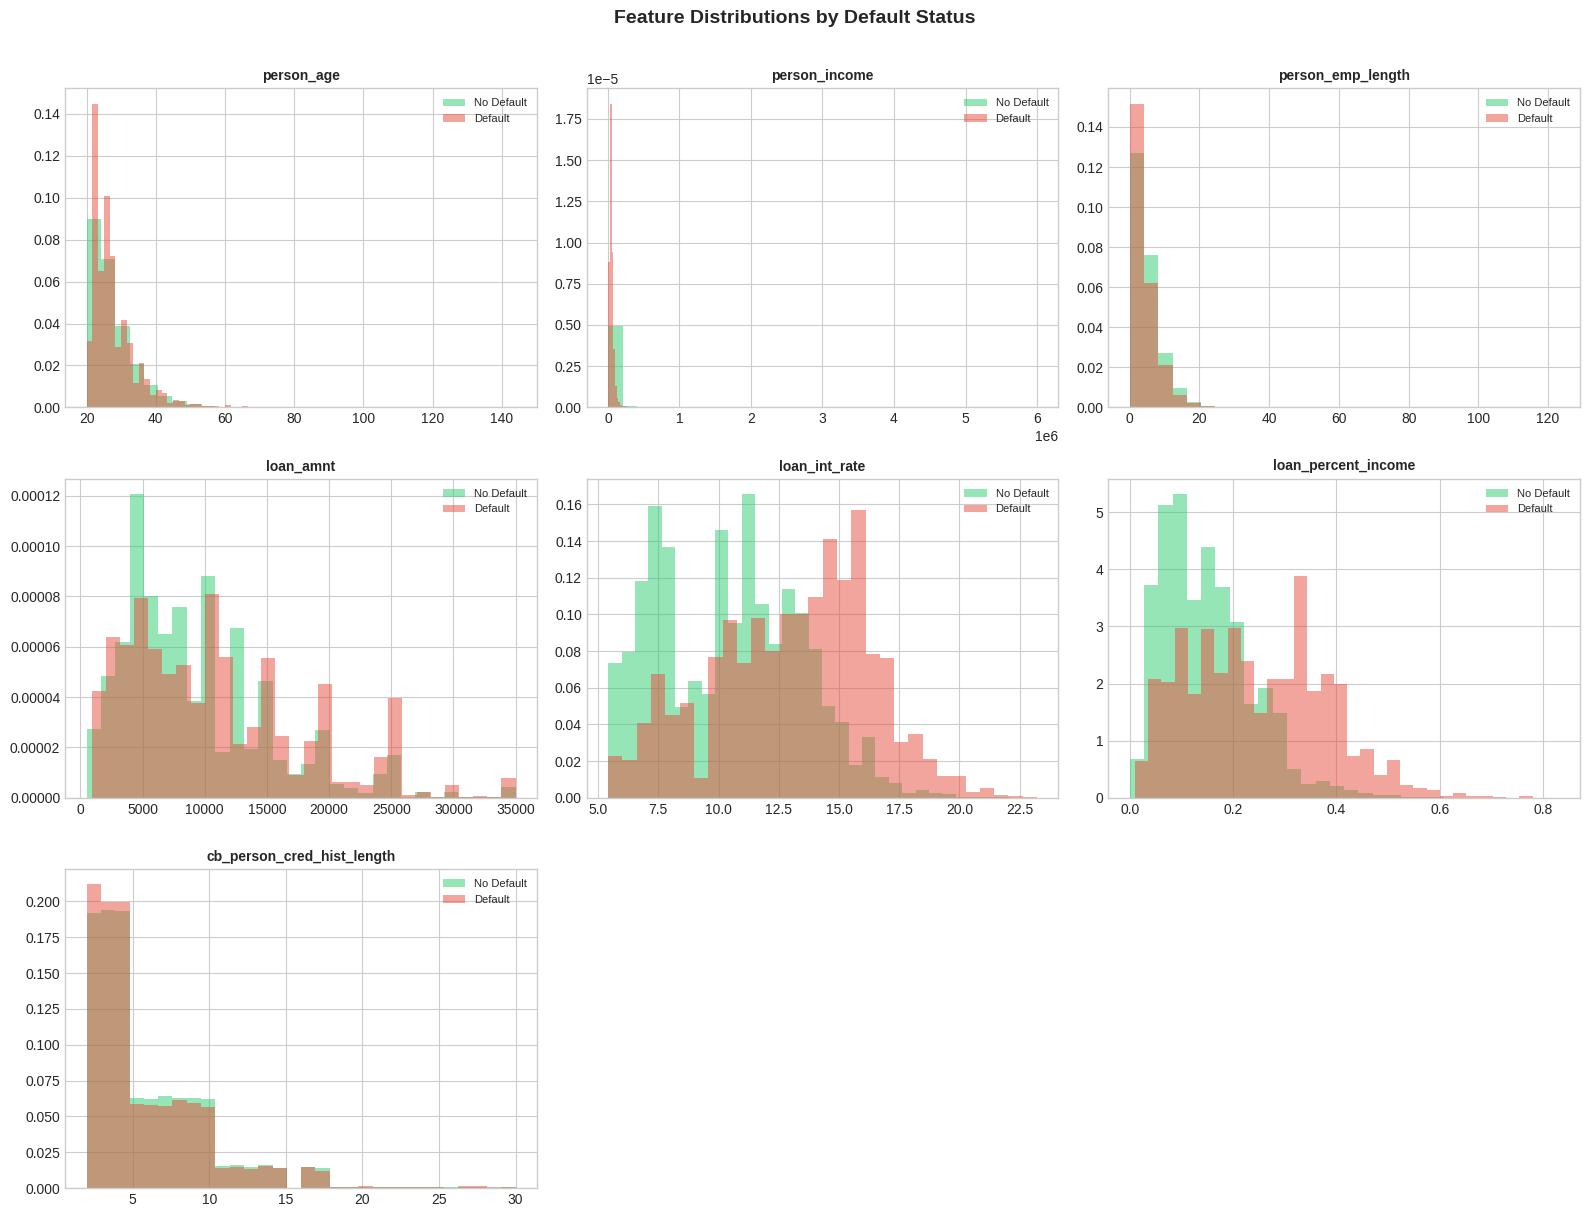

In [7]:
# === Numeric feature distributions ===
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_cols_p = 3
    n_rows_p = (len(plot_cols) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip(sorted(df[target_col].unique()),
                                       ['#2ecc71', '#e74c3c'], ['No Default', 'Default']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Feature Distributions by Default Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()


Categorical features: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


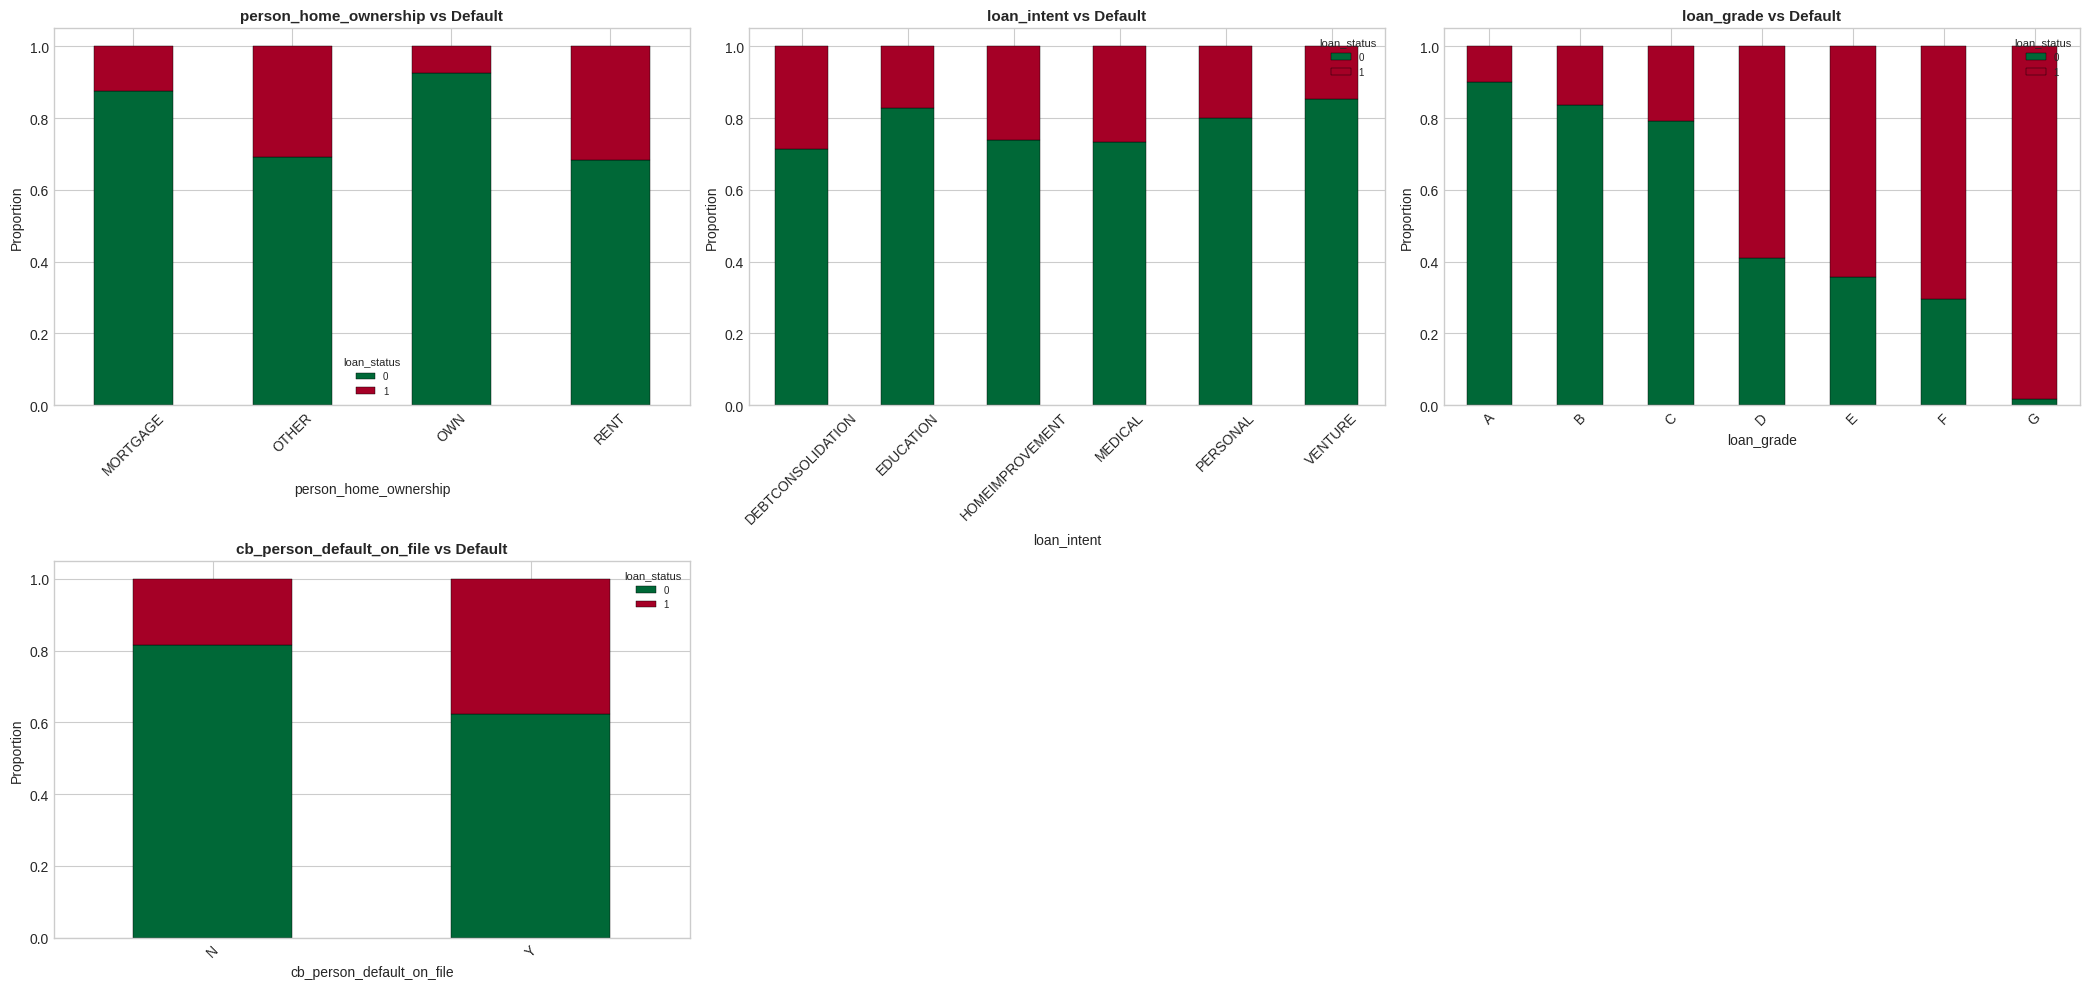

In [8]:
# === Categorical feature analysis ===
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15]

print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:6]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r',
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Default', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title=target_col, fontsize=7, title_fontsize=8)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()


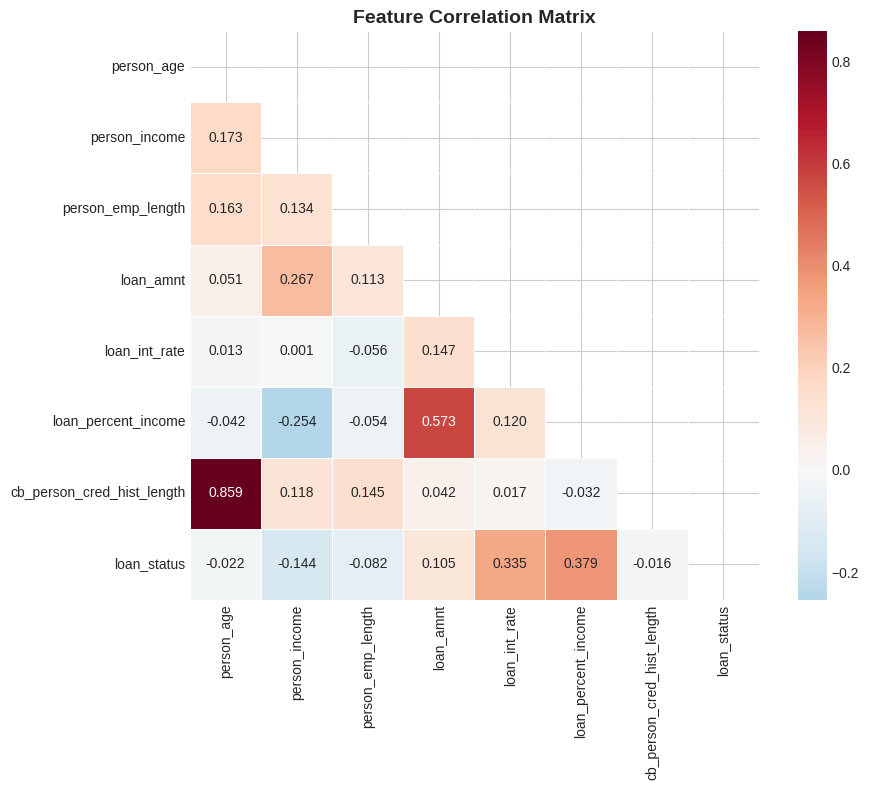

Correlations with default (absolute):
  loan_percent_income                 +0.3794
  loan_int_rate                       +0.3351
  person_income                       -0.1444
  loan_amnt                           +0.1054
  person_emp_length                   -0.0825
  person_age                          -0.0216
  cb_person_cred_hist_length          -0.0155


In [9]:
# === Correlation heatmap ===
if len(numeric_cols) > 1:
    corr_cols = numeric_cols + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Correlations with default (absolute):")
    for feat, val in target_corr.items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:35s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

Credit risk models benefit from domain features:
- **Loan-to-income ratio** — key affordability metric (ASIC responsible lending)
- **Age-employment interaction** — young + short employment = higher risk
- **Interest rate buckets** — risk-based pricing tiers
- Outlier capping for unrealistic ages/employment lengths


In [10]:
df_model = df.copy()

# Replace '?' with NaN
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_replaced = (df_model[col] == '?').sum()
        if n_replaced > 0:
            df_model[col] = df_model[col].replace('?', np.nan)
            print(f"  Replaced {n_replaced} '?' in '{col}'")

# Cap unrealistic values
for col in df_model.columns:
    if 'age' in col.lower() and df_model[col].dtype in ['int64', 'float64']:
        before = len(df_model[df_model[col] > 100])
        df_model.loc[df_model[col] > 100, col] = df_model[col].median()
        if before > 0:
            print(f"  Capped {before} unrealistic ages in '{col}'")
    if 'emp' in col.lower() and 'length' in col.lower() and df_model[col].dtype in ['int64', 'float64']:
        before = len(df_model[df_model[col] > 60])
        df_model.loc[df_model[col] > 60, col] = df_model[col].median()
        if before > 0:
            print(f"  Capped {before} unrealistic employment lengths in '{col}'")

# Drop ID columns
drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    print(f"  Dropping: {drop_cols}")
    df_model.drop(columns=drop_cols, inplace=True)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

print(f"\nTarget classes: {np.unique(y)} counts: {dict(zip(*np.unique(y, return_counts=True)))}")
assert len(np.unique(y)) >= 2

null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} missing values with median...")
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")


  Capped 5 unrealistic ages in 'person_age'
  Capped 2 unrealistic employment lengths in 'person_emp_length'
  Encoded 'person_home_ownership': 4 classes
  Encoded 'loan_intent': 6 classes
  Encoded 'loan_grade': 7 classes
  Encoded 'cb_person_default_on_file': 2 classes

Target classes: [0 1] counts: {np.int64(0): np.int64(25473), np.int64(1): np.int64(7108)}
Imputing 4011 missing values with median...

Feature matrix: (32581, 11)


In [11]:
# === Domain features ===
feature_names = X.columns.tolist()
composites_added = []

# Loan-to-income ratio (if not already present)
income_cols = [c for c in feature_names if 'income' in c.lower() and 'percent' not in c.lower()]
loan_amt_cols = [c for c in feature_names if 'loan_amnt' in c.lower() or 'loan_amount' in c.lower()]
if income_cols and loan_amt_cols:
    X['custom_loan_to_income'] = X[loan_amt_cols[0]] / (X[income_cols[0]] + 1)
    composites_added.append('custom_loan_to_income')
    print(f"Created 'custom_loan_to_income'")

# Interest rate bucket
rate_cols = [c for c in feature_names if 'int_rate' in c.lower() or 'rate' in c.lower()]
if rate_cols:
    X['rate_bucket'] = pd.cut(X[rate_cols[0]], bins=[0, 8, 12, 16, 25],
                               labels=[0, 1, 2, 3]).astype(float).fillna(1).astype(int)
    composites_added.append('rate_bucket')
    print(f"Created 'rate_bucket'")

# Age-employment interaction
age_cols = [c for c in feature_names if 'age' in c.lower() and 'vehicle' not in c.lower()]
emp_cols = [c for c in feature_names if 'emp' in c.lower() and 'length' in c.lower()]
if age_cols and emp_cols:
    X['age_emp_ratio'] = X[age_cols[0]] / (X[emp_cols[0]] + 1)
    composites_added.append('age_emp_ratio')
    print(f"Created 'age_emp_ratio'")

# Credit history length bucket
hist_cols = [c for c in feature_names if 'hist' in c.lower() or 'cred' in c.lower()]
if hist_cols:
    for hc in hist_cols:
        if X[hc].dtype in ['int64', 'float64'] and X[hc].nunique() > 5:
            X['credit_hist_bucket'] = pd.cut(X[hc], bins=[0, 3, 7, 15, 999],
                                              labels=[0, 1, 2, 3]).astype(float).fillna(1).astype(int)
            composites_added.append('credit_hist_bucket')
            print(f"Created 'credit_hist_bucket' from {hc}")
            break

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'custom_loan_to_income'
Created 'rate_bucket'
Created 'age_emp_ratio'
Created 'credit_hist_bucket' from cb_person_cred_hist_length

Total engineered: 4
Final feature count: 15


## 5. Model Training & Cross-Validation

Four-model comparison, 3-fold stratified CV. ROC-AUC primary metric.


In [12]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred
        fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}")
    
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba
    }
    print(f"  -- Mean Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.8363  F1=0.5254  AUC=0.8358  Prec=0.7151  Rec=0.4152
  Fold 2: Acc=0.8376  F1=0.5243  AUC=0.8309  Prec=0.7259  Rec=0.4103
  Fold 3: Acc=0.8324  F1=0.5089  AUC=0.8294  Prec=0.7053  Rec=0.3981
  -- Mean Acc: 0.8354  F1: 0.5195  AUC: 0.8320  Time: 15.08s

Training: Random Forest
  Fold 1: Acc=0.9266  F1=0.8052  AUC=0.9255  Prec=0.9570  Rec=0.6949
  Fold 2: Acc=0.9272  F1=0.8081  AUC=0.9254  Prec=0.9498  Rec=0.7033
  Fold 3: Acc=0.9257  F1=0.8028  AUC=0.9308  Prec=0.9530  Rec=0.6935
  -- Mean Acc: 0.9265  F1: 0.8054  AUC: 0.9272  Time: 4.76s

Training: XGBoost
  Fold 1: Acc=0.9356  F1=0.8342  AUC=0.9492  Prec=0.9528  Rec=0.7418
  Fold 2: Acc=0.9365  F1=0.8358  AUC=0.9463  Prec=0.9580  Rec=0.7412
  Fold 3: Acc=0.9338  F1=0.8297  AUC=0.9481  Prec=0.9450  Rec=0.7396
  -- Mean Acc: 0.9353  F1: 0.8332  AUC: 0.9479  Time: 0.77s

Training: LightGBM
  Fold 1: Acc=0.9367  F1=0.8337  AUC=0.9481  Prec=0.9779  Rec=0.7266
  Fold 2: Acc=0.9350  F1=0.8283  A

## 6. Model Comparison & Selection

In [14]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn, 'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s", 'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier   Time
            XGBoost 0.9353 +/- 0.0011 0.8332 +/- 0.0026 0.9479 +/- 0.0012 0.0525  0.77s
           LightGBM 0.9358 +/- 0.0007 0.8311 +/- 0.0022 0.9462 +/- 0.0028 0.0528  0.97s
      Random Forest 0.9265 +/- 0.0006 0.8054 +/- 0.0022 0.9272 +/- 0.0025 0.0627  4.76s
Logistic Regression 0.8354 +/- 0.0022 0.5195 +/- 0.0075 0.8320 +/- 0.0028 0.1207 15.08s

Best model: XGBoost


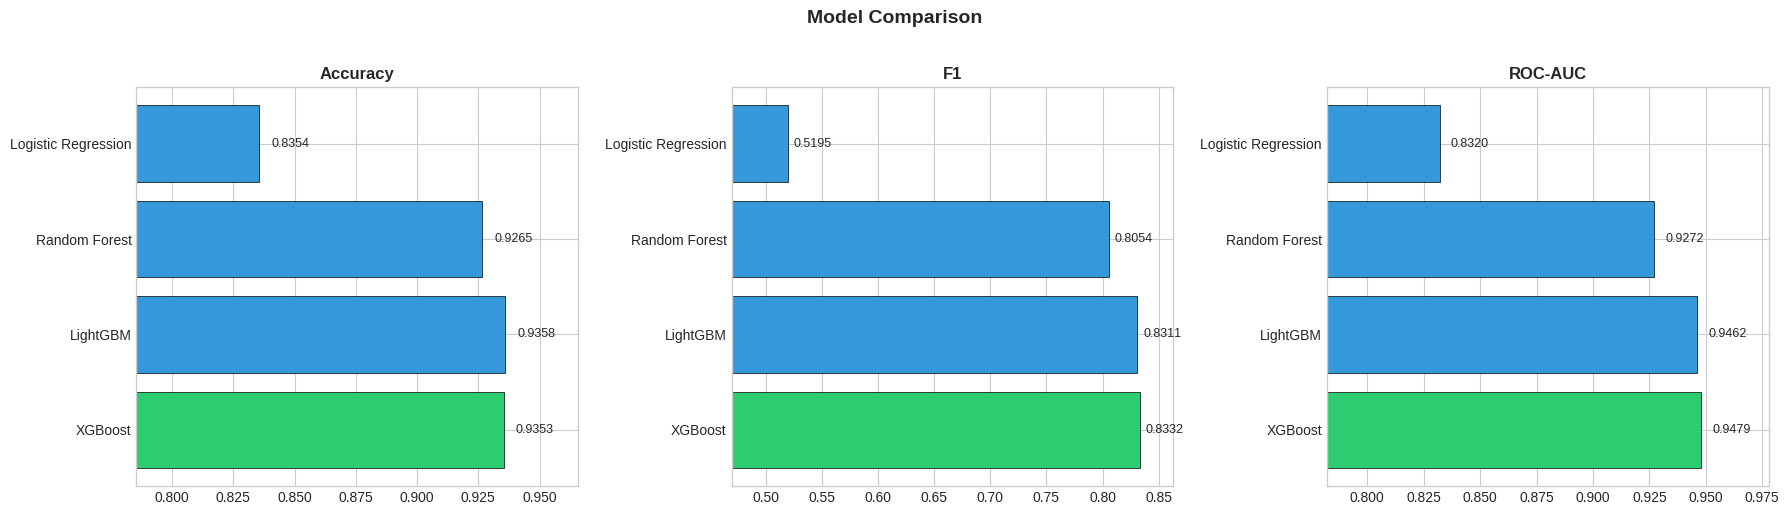

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For credit risk:
- **False negatives** (missed defaults) = financial loss, increased non-performing loans
- **False positives** (rejecting good borrowers) = lost revenue, potential discrimination complaints (AFCA)
- Threshold reflects risk appetite and regulatory capital requirements


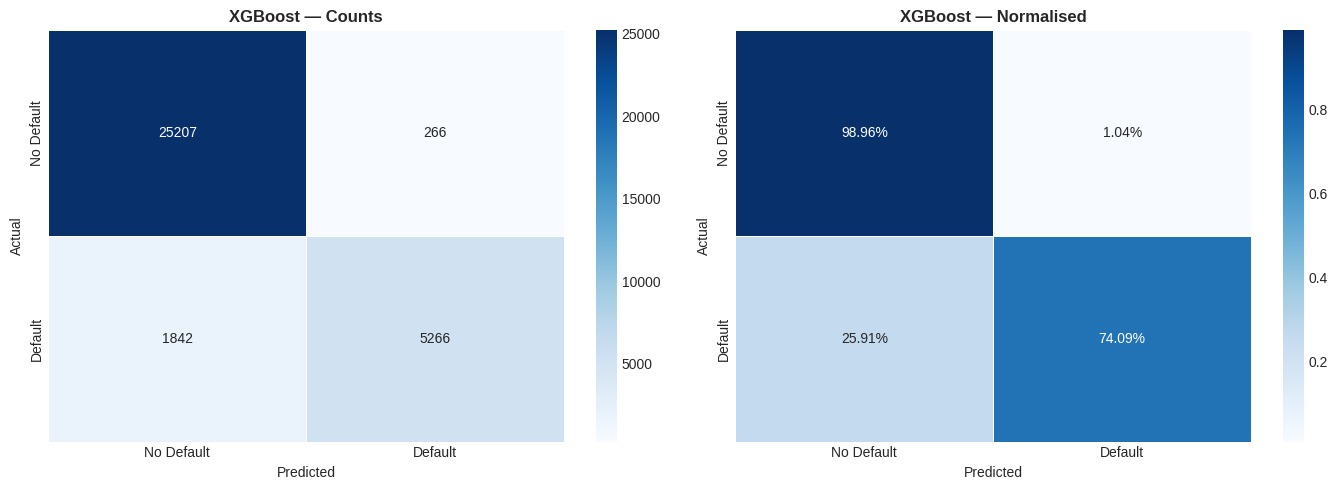


CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

  No Default       0.93      0.99      0.96     25473
     Default       0.95      0.74      0.83      7108

    accuracy                           0.94     32581
   macro avg       0.94      0.87      0.90     32581
weighted avg       0.94      0.94      0.93     32581



In [16]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['No Default', 'Default']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\nCLASSIFICATION REPORT — {best_model_name}")
print("=" * 60)
print(classification_report(y, best_preds, target_names=cm_labels))


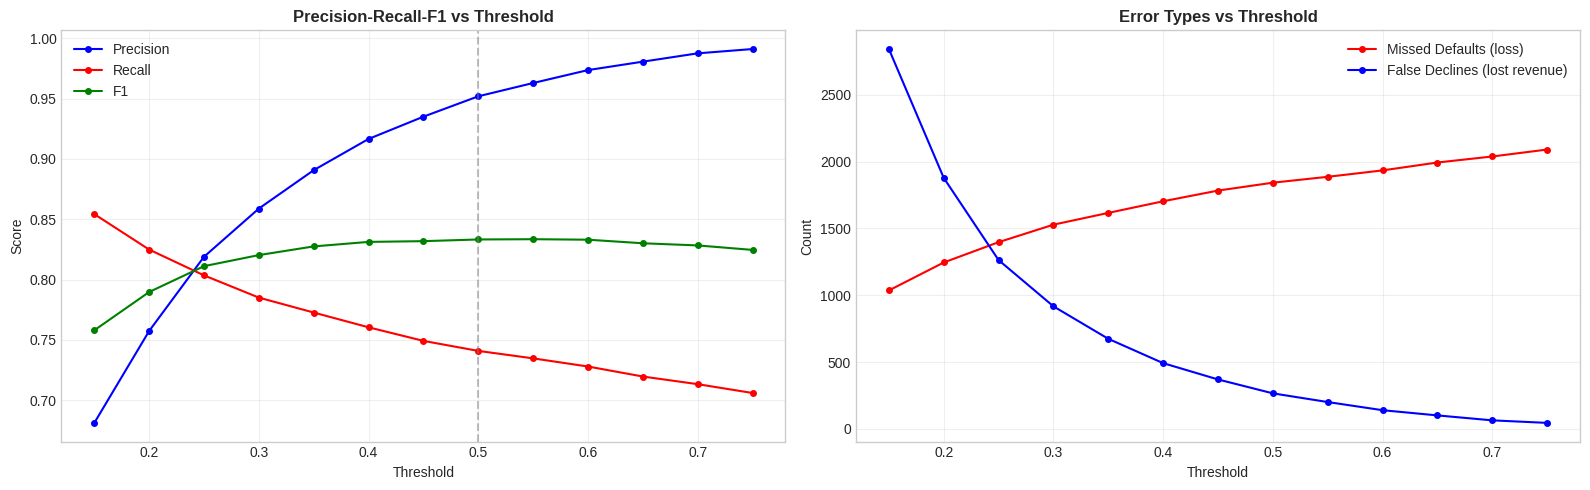


Optimal threshold (F1): 0.55


In [17]:
thresholds = np.arange(0.15, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Default (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Decline (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision', ms=4)
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', label='Recall', ms=4)
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', label='F1', ms=4)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Default (FN)'], 'r-o', label='Missed Defaults (loss)', ms=4)
axes[1].plot(thresh_df['Threshold'], thresh_df['False Decline (FP)'], 'b-o', label='False Declines (lost revenue)', ms=4)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()

best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")


## 8. Feature Importance & Policy Insights

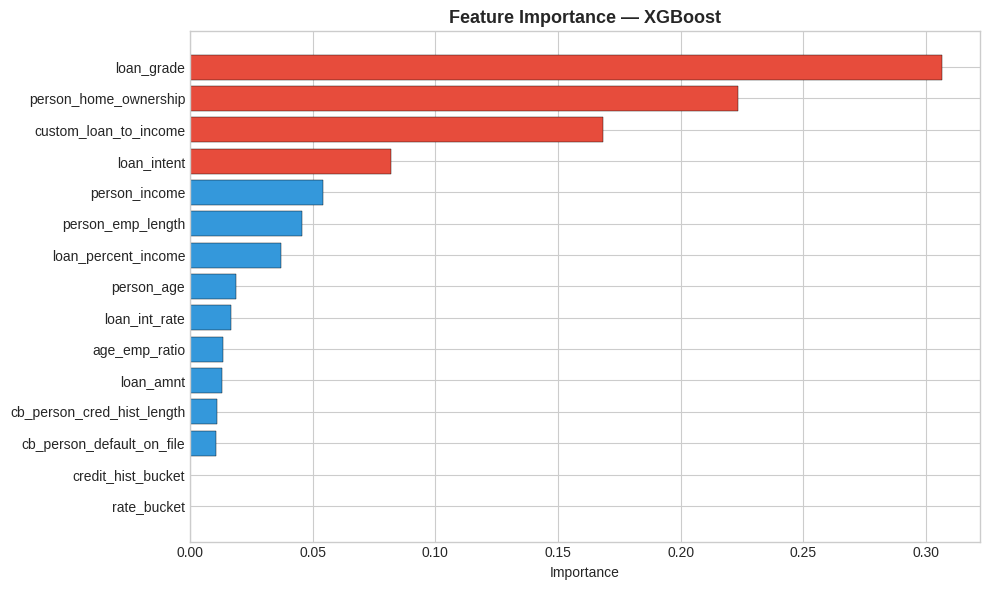

TOP 5 PREDICTIVE FEATURES
  loan_grade                           0.3067
  person_home_ownership                0.2232
  custom_loan_to_income                0.1681
  loan_intent                          0.0817
  person_income                        0.0541


In [18]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


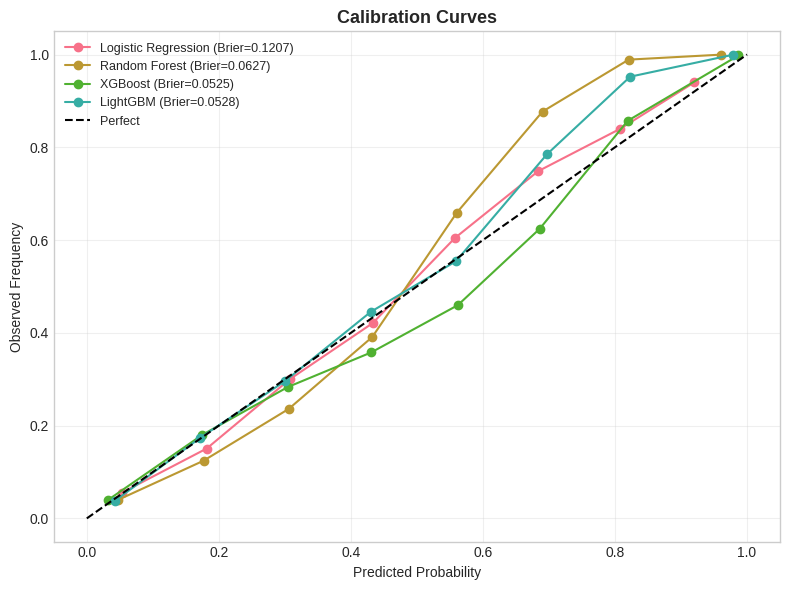

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [20]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)

checks = {
    'AUC > 0.70': best_res['auc_mean'] > 0.70,
    'F1 > 0.40': best_res['f1_mean'] > 0.40,
    'Brier < 0.20': best_res['brier_mean'] < 0.20,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    XGBoost
  ROC-AUC:              0.9479
  F1:                   0.8332
  Precision:            0.9519
  Recall:               0.7409
  Brier Score:          0.0525
  Training time:        0.8s
  Feature count:        15
  Dataset rows:         32,581
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.55

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.70
  [pass] F1 > 0.40
  [pass] Brier < 0.20
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [21]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Core banking system, credit bureau (Equifax/Illion/Experian AU)
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Databricks Feature Store / Fabric gold layer
   Schedule: Real-time scoring at application + nightly batch portfolio

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Azure ML real-time (<200ms per application)
   Batch: Nightly portfolio-level risk reassessment
   Fallback: Rule-based scorecard if model unavailable

3. INTEGRATION POINTS
   Origination: Auto-decision engine (approve/refer/decline)
   Portfolio: Power BI dashboard (PD/LGD/EAD by segment)
   Collections: Early warning triggers for deteriorating accounts
   Regulatory: APRA quarterly capital adequacy reporting (APS 220)

4. FAIRNESS & GOVERNANCE
   Protected: Age, gender, marital status, postcode (proxy for race)
   Fairness: Demographic parity, equalised odds monitoring
   Explainability: SHAP values for declined applications (ASIC requirement)
   Human-in-the-loop: All declines reviewable by credit analyst
   Compliance: NCCPA responsible lending, Privacy Act, Anti-Discrimination Act

5. MONITORING & RETRAINING
   Drift: PSI on application features monthly
   Performance: Gini coefficient on 12-month default outcomes
   Retraining: Quarterly with confirmed default/non-default labels
   Backtesting: Compare predicted vs actual default rates by cohort
   Stress testing: APRA mandated scenario analysis

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Core banking system, credit bureau (Equifax/Illion/Experian AU)
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Databricks Feature Store / Fabric gold layer
   Schedule: Real-time scoring at application + nightly batch portfolio

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Azure ML real-time (<200ms per application)
   Batch: Nightly portfolio-level risk reassessment
   Fallback: Rule-based scorecard if model unavailable

3. INTEGRATION POINTS
   Origination: Auto-decision engine (approve/refer/decline)
   Portfolio: Power BI dashboard (PD/LGD/EAD by segment)
   Collections: Early warning triggers for deteriorating accounts
   Regulatory: APRA quarterly capital adequacy reporting (APS 220)

4. FAIRNESS & GOVERNANCE
   Protected: Age, gender, marital status, postcode (proxy for race)
   Fairness: Demographic parity, equalised odds monitoring
   Explainability: SHAP va